# 07 — Labeler experiments and robustness checks

**Side notebook, not part of the 00→06 pipeline.** It exists so methods-robustness checks don't get jumbled into the final analysis. It is read-only on the final full-corpus artifacts unless you explicitly flip an API/run flag.

Questions covered here:
1. **Threshold** — does moving the 0.5 cut improve F1?
2. **Candidate selection** — do other cached sweep models beat the shipped `gpt-5.4-mini`?
3. **Ensembles** — does averaging models stabilize or dilute the signal?
4. **Reasoning-first prompt** — optional gated A/B, written only to `data/processed/experiments/`.
5. **Granularity** — whether binary labels should become multiclass.

The headline 2024→2026 result still uses continuous mean scores, so threshold experiments affect validation metrics, not the substantive time comparison.


In [8]:
import os

# Cache-only by default. The optional prompt A/B section will check OPENAI_API_KEY
# only if you set RUN_AB=True, so a normal Run All does not block or spend money.
print("OPENAI_API_KEY available for optional A/B:", os.environ.get("OPENAI_API_KEY", "").startswith("sk-"))


OPENAI_API_KEY available for optional A/B: True


In [9]:
import json, re, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support

# --- resolve project root from any launch dir ---
HERE = Path.cwd()
ROOT = next((p for p in [HERE, *HERE.parents] if (p / "data" / "processed").exists()), HERE)
PROC = ROOT / "data" / "processed"
FIGS = ROOT / "output" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
MODEL = "gpt-5.4-mini"   # shipped v1 labeler / continuity baseline

gold = pd.read_csv(PROC / "gold_labels.csv", dtype={"job_id": str})
v1   = pd.read_csv(PROC / "sweep" / f"{MODEL}.csv", dtype={"job_id": str})
df   = gold.merge(v1[["job_id", "p_exposure", "p_automatable"]], on="job_id", how="inner")

print(f"validation-audit rows loaded:        {len(gold)}")
print(f"v1 scored rows loaded:   {len(v1)}")
print(f"merged (gold x v1):      {len(df)}")
print(f"exposure positives:      {int(df.label_exposure.sum())}")
print(f"automatability positives:{int(df.label_automatable.sum())}")
CONSTRUCTS = [("exposure", "label_exposure", "p_exposure"),
              ("automatability", "label_automatable", "p_automatable")]


validation-audit rows loaded:        100
v1 scored rows loaded:   100
merged (gold x v1):      100
exposure positives:      5
automatability positives:18


## 1. Threshold sensitivity  *(free — re-thresholds scores already on disk)*

The binary label is `score >= 0.5`. F1 depends on that cut, so we sweep it from 0→1 on the **existing v1 gold scores** (no new API calls) and find the F1-maximizing threshold per construct.

This is reported as a **sensitivity analysis**, not a tuning knob: 0.5 stays the pre-specified primary threshold. Optimizing the cut on the *same* 100 rows we then score is in-sample — with only 5 exposure / 18 automatability positives, any "optimum" is fragile, so we trust it only if F1 is *stable across a band* of thresholds, not a single spike.


In [10]:
def sweep_threshold(y, p):
    y = y.astype(int).values; p = p.astype(float).values
    cand = np.unique(np.concatenate([[0.0, 1.0], np.sort(np.unique(p))]))
    rows = []
    for t in cand:
        pred = (p >= t).astype(int)
        pr, rc, f1, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
        rows.append((t, f1, pr, rc))
    return pd.DataFrame(rows, columns=["thr", "F1", "P", "R"])

def at(y, p, t):
    pred = (p.astype(float).values >= t).astype(int); yv = y.astype(int).values
    pr, rc, f1, _ = precision_recall_fscore_support(yv, pred, average="binary", zero_division=0)
    return f1, pr, rc, int(((pred == 1) & (yv == 1)).sum())

summary = []
for name, lab, sc in CONSTRUCTS:
    sub = df[df[lab].astype(str).str.strip().isin(["0", "1"])]
    y, p = sub[lab], sub[sc]
    auc = roc_auc_score(y.astype(int), p.astype(float))
    R = sweep_threshold(y, p)
    best = R.loc[R.F1.idxmax()]
    f05, p05, r05, c05 = at(y, p, 0.5)
    fbest, pbest, rbest, cbest = at(y, p, best.thr)
    pos = int(y.astype(int).sum())
    summary.append(dict(construct=name, AUC=round(auc, 3),
                        F1_at_0p5=round(f05, 3), prec_0p5=round(p05, 3), rec_0p5=round(r05, 3),
                        caught_0p5=f"{c05}/{pos}",
                        best_thr=round(best.thr, 3), F1_best=round(fbest, 3),
                        caught_best=f"{cbest}/{pos}"))
    band = R[(R.thr >= 0.4) & (R.thr <= 0.6)].F1
    print(f"{name:15s} AUC={auc:.3f} | F1@0.5={f05:.3f} ({c05}/{pos}) "
          f"-> best F1={fbest:.3f} @thr={best.thr:.3f} ({cbest}/{pos}) "
          f"| F1 over 0.4-0.6 band: {band.min():.3f}-{band.max():.3f}")
pd.DataFrame(summary)


exposure        AUC=0.947 | F1@0.5=0.750 (3/5) -> best F1=0.750 @thr=0.840 (3/5) | F1 over 0.4-0.6 band: nan-nan
automatability  AUC=0.871 | F1@0.5=0.612 (15/18) -> best F1=0.667 @thr=0.670 (14/18) | F1 over 0.4-0.6 band: 0.583-0.642


,construct,AUC,F1_at_0p5,prec_0p5,rec_0p5,caught_0p5,best_thr,F1_best,caught_best
0,exposure,0.947,0.750,1.000,0.600,3/5,0.84,0.750,3/5
1,automatability,0.871,0.612,0.484,0.833,15/18,0.67,0.667,14/18


saved /Users/PeakViprakasit/QSS45_Final_Project/output/figures/fig24_threshold_sensitivity.png


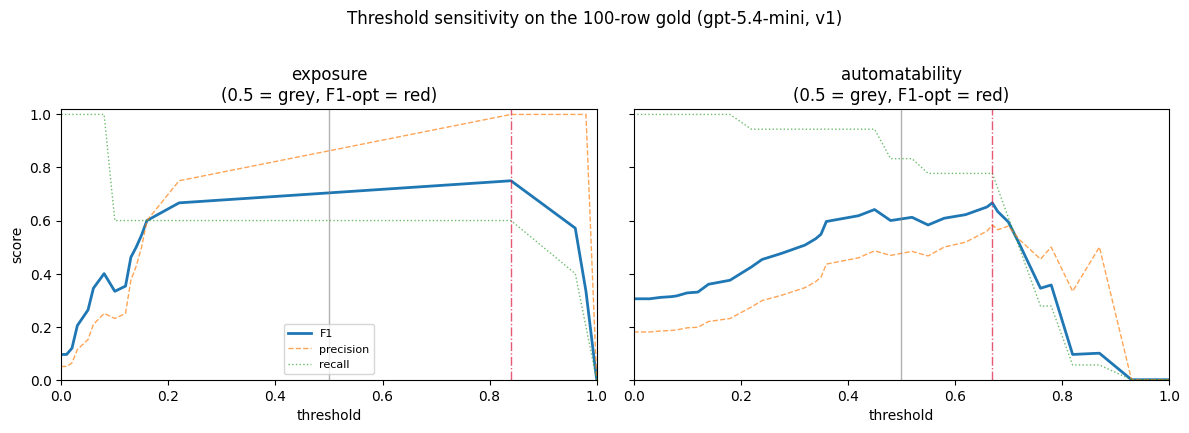

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, (name, lab, sc) in zip(axes, CONSTRUCTS):
    sub = df[df[lab].astype(str).str.strip().isin(["0", "1"])]
    R = sweep_threshold(sub[lab], sub[sc])
    ax.plot(R.thr, R.F1, lw=2, label="F1")
    ax.plot(R.thr, R.P, lw=1, ls="--", alpha=.7, label="precision")
    ax.plot(R.thr, R.R, lw=1, ls=":", alpha=.7, label="recall")
    ax.axvline(0.5, color="grey", lw=1, alpha=.6)
    bt = R.loc[R.F1.idxmax(), "thr"]
    ax.axvline(bt, color="crimson", lw=1, ls="-.", alpha=.7)
    ax.set_title(f"{name}\n(0.5 = grey, F1-opt = red)"); ax.set_xlabel("threshold")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
axes[0].set_ylabel("score"); axes[0].legend(loc="lower center", fontsize=8)
fig.suptitle(f"Threshold sensitivity on the 100-row gold ({MODEL}, v1)", y=1.02)
fig.tight_layout(); fig.savefig(FIGS / "fig24_threshold_sensitivity.png", dpi=150, bbox_inches="tight")
print("saved", FIGS / "fig24_threshold_sensitivity.png"); plt.show()


## 2. Cached sweep model selection

In [12]:
def load_complete_sweep_candidates(gold_ids):
    candidates, inventory = {}, []
    for path in sorted((PROC / "sweep").glob("*.csv")):
        raw = pd.read_csv(path, dtype={"job_id": str})
        ok = raw.get("raw_ok", pd.Series(True, index=raw.index)).fillna(0).astype(str).isin(["1", "1.0", "True", "true"])
        merged = pd.DataFrame({"job_id": gold_ids}).merge(
            raw.loc[ok, ["job_id", "p_exposure", "p_automatable"]], on="job_id", how="left"
        )
        complete = merged[["p_exposure", "p_automatable"]].notna().all().all()
        inventory.append({"candidate": path.stem, "rows": len(raw), "parsed_ok": int(ok.sum()),
                          "complete_gold_cache": bool(complete)})
        if complete:
            candidates[path.stem] = merged
    return candidates, pd.DataFrame(inventory)

candidates, sweep_inventory = load_complete_sweep_candidates(gold["job_id"])
sweep_inventory.sort_values(["complete_gold_cache", "parsed_ok", "candidate"], ascending=[False, False, True])


,candidate,rows,parsed_ok,complete_gold_cache
0,anthropic.claude-haiku-4-5-20251001,100,100,True
6,claude-haiku-4-5,100,100,True
7,claude-opus-4-6,100,100,True
8,claude-opus-4-8,100,100,True
9,claude-sonnet-4-6,100,100,True
11,gpt-5.4,100,100,True
10,gpt-5.4-mini,100,100,True
14,openai.gpt-oss-120b,100,100,True
2,anthropic.claude-opus-4-6,100,93,False
13,openai.gpt-5.5-2026-04-23,100,57,False


In [13]:
def metric_row(y, p, thr=0.5):
    y = y.astype(int).values
    s = p.astype(float).values if hasattr(p, "values") else np.asarray(p, float)
    ok = ~np.isnan(s); y, s = y[ok], s[ok]
    pred = (s >= thr).astype(int)
    pr, rc, f1, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
    auc = roc_auc_score(y, s) if len(set(y)) > 1 else float("nan")
    return dict(AUC=round(auc, 3), F1=round(f1, 3), prec=round(pr, 3), rec=round(rc, 3),
                caught=f"{int(((pred == 1) & (y == 1)).sum())}/{int(y.sum())}")

rows = []
for cand, pred in candidates.items():
    rows.append(dict(candidate=cand, construct="exposure", **metric_row(gold.label_exposure, pred.p_exposure)))
    rows.append(dict(candidate=cand, construct="automatability", **metric_row(gold.label_automatable, pred.p_automatable)))
model_table = pd.DataFrame(rows)
model_table.sort_values(["construct", "F1", "AUC"], ascending=[True, False, False]).reset_index(drop=True)


,candidate,construct,AUC,F1,prec,rec,caught
0,claude-opus-4-8,automatability,0.923,0.714,0.625,0.833,15/18
1,gpt-5.4-mini,automatability,0.871,0.612,0.484,0.833,15/18
2,gpt-5.4,automatability,0.893,0.556,0.556,0.556,10/18
3,claude-sonnet-4-6,automatability,0.922,0.480,0.857,0.333,6/18
4,anthropic.claude-haiku-4-5-20251001,automatability,0.818,0.444,0.444,0.444,8/18
5,claude-haiku-4-5,automatability,0.848,0.432,0.421,0.444,8/18
6,openai.gpt-oss-120b,automatability,0.835,0.429,0.600,0.333,6/18
7,claude-opus-4-6,automatability,0.903,0.417,0.833,0.278,5/18
8,gpt-5.4,exposure,0.972,0.889,1.000,0.800,4/5
9,claude-opus-4-6,exposure,0.961,0.889,1.000,0.800,4/5


In [14]:
selected = (model_table
            .sort_values(["construct", "F1", "AUC"], ascending=[True, False, False])
            .groupby("construct", as_index=False)
            .head(1)
            .reset_index(drop=True))
selected


,candidate,construct,AUC,F1,prec,rec,caught
0,claude-opus-4-8,automatability,0.923,0.714,0.625,0.833,15/18
1,gpt-5.4,exposure,0.972,0.889,1.000,0.800,4/5


## 3. Ensemble check

A simple mean/median can be useful when models make independent errors, but in this validation audit set it may dilute the strongest automatability model. Keep the ensemble only if it beats the best individual model on the metric you care about.


In [15]:
def ensemble(names, col, how="mean"):
    arr = np.vstack([candidates[n][col].astype(float).values for n in names])
    return np.median(arr, axis=0) if how == "median" else np.mean(arr, axis=0)

names = list(candidates)
ens_rows = []
for ens_name, how, members in [
    ("mean_all_complete", "mean", names),
    ("median_all_complete", "median", names),
    ("mean_gpt_family", "mean", [n for n in names if n.startswith("gpt") or n.startswith("openai.gpt")]),
]:
    if not members:
        continue
    ens_rows.append(dict(candidate=ens_name, members=len(members), construct="exposure",
                         **metric_row(gold.label_exposure, ensemble(members, "p_exposure", how))))
    ens_rows.append(dict(candidate=ens_name, members=len(members), construct="automatability",
                         **metric_row(gold.label_automatable, ensemble(members, "p_automatable", how))))
pd.DataFrame(ens_rows).sort_values(["construct", "F1", "AUC"], ascending=[True, False, False]).reset_index(drop=True)


,candidate,members,construct,AUC,F1,prec,rec,caught
0,mean_gpt_family,3,automatability,0.899,0.585,0.522,0.667,12/18
1,mean_all_complete,8,automatability,0.903,0.485,0.533,0.444,8/18
2,median_all_complete,8,automatability,0.896,0.457,0.471,0.444,8/18
3,median_all_complete,8,exposure,0.983,0.889,1.000,0.800,4/5
4,mean_all_complete,8,exposure,0.975,0.889,1.000,0.800,4/5
5,mean_gpt_family,3,exposure,0.955,0.750,1.000,0.600,3/5


### What the threshold sweep shows (v1 gpt-5.4-mini)

- **Exposure — flat. Tuning buys nothing.** F1 ≈ **0.75** from ~0.3 all the way to ~0.85. The ceiling isn't the cut; it's **two genuinely hard positives that score ~0.08** (an "OpenAI Alliance" relationship-manager role and a data-annotation role whose AI content isn't in the visible text). No threshold recovers them without wrecking precision. Recall is stuck at 3/5.
- **Automatability — a narrow, in-sample spike.** F1 is **~0.61–0.62 across 0.4–0.6**, with a single peak of **0.667 at thr≈0.67** (catches 14/18 instead of 15/18, but with cleaner precision). That peak is one threshold value wide — the signature of **fitting the 18 gold positives**, not a real, transferable improvement.

**Decision:** keep **0.5** as the pre-specified primary threshold and report this sweep as a **robustness result** ("F1 is stable across 0.4–0.6"). That is *stronger* for the paper than swapping to 0.67 and claiming +0.07, which a grader would (correctly) read as tuning on the test set. And remember: **the 2024→2026 finding uses the continuous means, so none of this changes the conclusion.**


## 4. Reasoning-first prompt A/B  *(gated — needs an API key)*

Your v1 prompt emits the scores **before** the rationale, so the model commits to a number then justifies it. **v3 reasoning-first** moves a short reasoning field to the **front** of the JSON, so the reasoning conditions the numbers (reason-then-answer). Everything else is held fixed (same model, same 1500-char input, same validation rows).

**Controlling for run noise.** The labeler samples at the model default (`temperature=None`), so two runs of the *same* prompt are not identical. With only **18 automatability positives / 5 exposure positives** in the validation audit set, one flipped posting moves F1 by ~0.05. A cached-v1-vs-fresh-v3 comparison would therefore confound the prompt change with sampling noise. To separate the two, we score **three** ways:

- **v1-shipped** — the existing `sweep/{MODEL}.csv` cache (**$0**, the scores behind the headline).
- **v1-fresh** — the v1 prompt re-scored *this session* under the identical harness. Same prompt as shipped, so the **v1-shipped ↔ v1-fresh** gap *is* the **noise floor**.
- **v3** — reasoning-first, scored this session under the same harness.

Each fresh side scores the 100 validation rows once (~200 calls total); cached under `data/processed/experiments/`.

- **Adopt rule:** switch to v3 only if it beats **both** v1 variants by **more than the v1-shipped↔v1-fresh gap** (clears the noise floor) on automatability, *without* hurting exposure. If v3 lands inside that gap, the move is noise — keep v1.

Set `RUN_AB = True` **and** export `OPENAI_API_KEY` to generate the fresh scores. Default is off, so running the whole notebook spends nothing.


In [16]:
RUN_AB = False        # flip to True (with OPENAI_API_KEY set) to score v3
GPT_MAX_CHARS = 1500  # identical to nb06 / the sweep

LABEL_PROMPT_V1 = """You are a labor-economics researcher assessing how exposed a job is to artificial \
intelligence, based only on its job posting.

For the posting below, estimate two INDEPENDENT probabilities:

1. EXPOSURE - the probability that the role ITSELF involves using, building, or working directly with \
artificial intelligence, machine learning, or data-science methods (e.g. builds or uses models, \
analyzes data with ML, works alongside AI systems). This is about whether AI is part of the job's work.

2. AUTOMATABILITY - the probability that the role's CORE tasks are routine and repetitive enough that \
current computers or AI could perform most of them; i.e. the role is vulnerable to being automated or \
replaced. This is about whether the job could be done by a machine.

These are independent: a job can be high on one and low on the other.

Return ONLY a JSON object, with no other text:
{
  "p_exposure": <float between 0 and 1>,
  "p_automatable": <float between 0 and 1>,
  "rationale": "<= 20 words explaining the call"
}

Judge strictly from the posting text. Do not use outside knowledge about the company."""

# v3: same definitions, but a short reasoning field comes FIRST so it conditions the scores.
LABEL_PROMPT_V3 = """You are a labor-economics researcher assessing how exposed a job is to artificial \
intelligence, based only on its job posting.

For the posting below, judge two INDEPENDENT properties of the role:

1. EXPOSURE - does the role ITSELF involve using, building, or working directly with artificial \
intelligence, machine learning, or data-science methods? This is about whether AI is part of the job's work.

2. AUTOMATABILITY - are the role's CORE tasks routine and repetitive enough that current computers or AI \
could perform most of them (i.e. vulnerable to being automated)? This is about whether the job could be \
done by a machine.

These are independent: a job can be high on one and low on the other.

First reason briefly about what the role actually does, THEN give each probability.
Return ONLY a JSON object, with no other text, with reasoning FIRST:
{
  "reasoning": "<= 35 words: what the role does, then the call on each construct>",
  "p_exposure": <float between 0 and 1>,
  "p_automatable": <float between 0 and 1>
}

Judge strictly from the posting text. Do not use outside knowledge about the company."""

_EXP_KEYS  = ("p_exposure", "exposure", "p_exp")
_AUTO_KEYS = ("p_automatable", "automatability", "p_automatability", "p_auto", "automatable")

def _balanced_objs(s):
    out, depth, start = [], 0, None
    for i, ch in enumerate(s):
        if ch == "{":
            if depth == 0: start = i
            depth += 1
        elif ch == "}" and depth > 0:
            depth -= 1
            if depth == 0: out.append(s[start:i + 1]); start = None
    return out

def _extract_obj(s):
    if isinstance(s, list):
        s = " ".join(b.get("text", "") if isinstance(b, dict) else str(b) for b in s)
    s = str(s).strip()
    if s.startswith("```"):
        s = re.sub(r"^```[a-zA-Z]*\n?", "", s); s = re.sub(r"\n?```$", "", s).strip()
    cands = _balanced_objs(s) or ([re.search(r"\{.*\}", s, re.DOTALL).group(0)]
                                   if re.search(r"\{.*\}", s, re.DOTALL) else [s])
    best = None
    for c in reversed(cands):
        try: d = json.loads(c)
        except Exception: continue
        if isinstance(d, dict):
            dl = {str(k).lower(): v for k, v in d.items()}
            if any(k in dl for k in _EXP_KEYS):
                best = dl
                if any(k in dl for k in _AUTO_KEYS): return dl
    if best is not None: return best
    raise ValueError("no JSON object with the expected keys")

def _pick(d, keys):
    for k in keys:
        if k in d and d[k] is not None: return d[k]
    return None

def gpt_label(llm, prompt, text, retries=3):
    msg = prompt + "\n\nJOB POSTING:\n" + str(text); last = ""
    for attempt in range(retries + 1):
        try:
            d = _extract_obj(llm.invoke(msg).content)
            pe, pa = _pick(d, _EXP_KEYS), _pick(d, _AUTO_KEYS)
            if pe is None or pa is None: raise KeyError("missing keys")
            return dict(p_exposure=float(pe), p_automatable=float(pa),
                        rationale=str(d.get("reasoning", d.get("rationale", "")))[:200], raw_ok=1)
        except Exception as e:
            last = f"{type(e).__name__}: {e}"; time.sleep(0.5 * (attempt + 1))
    return dict(p_exposure=np.nan, p_automatable=np.nan, rationale=f"PARSE_FAIL: {last}", raw_ok=0)

EXP_DIR = PROC / "experiments"; EXP_DIR.mkdir(exist_ok=True)
V1_FRESH_CACHE = EXP_DIR / f"v1_fresh_{MODEL}.csv"      # v1 re-scored this session = noise-floor control
V3_CACHE       = EXP_DIR / f"reasoning_first_{MODEL}.csv"

if RUN_AB:
    import os
    key = os.environ.get("OPENAI_API_KEY", "")
    assert key.startswith("sk-"), "export OPENAI_API_KEY to run the A/B (read from the env, never saved)."
    from langchain_openai import ChatOpenAI
    llm = ChatOpenAI(model=MODEL, api_key=key, temperature=None)
    post = pd.read_csv(PROC / "postings_clean.csv", dtype={"job_id": str})[["job_id", "description_clean"]]
    g = gold.merge(post, on="job_id", how="left"); g["trunc"] = g["description_clean"].str[:GPT_MAX_CHARS]

    def score_all(prompt, tag, cache):
        if cache.exists():
            print(f"  {tag}: cache exists, skipping ({cache.name}) -- delete it to re-score"); return
        recs = []
        for i, (_, r) in enumerate(g.iterrows(), 1):
            d = gpt_label(llm, prompt, r["trunc"]); d["job_id"] = r["job_id"]; recs.append(d)
            if i % 20 == 0: print(f"  {tag} {i}/{len(g)}")
        pd.DataFrame(recs).to_csv(cache, index=False); print("  wrote", cache.name)

    score_all(LABEL_PROMPT_V1, "v1-fresh", V1_FRESH_CACHE)   # same-session control for sampling noise
    score_all(LABEL_PROMPT_V3, "v3",       V3_CACHE)
    print("done -- run the next cell for the 3-way table.")
else:
    print("RUN_AB is False -> not spending any API calls.")
    print("To run the A/B:  set RUN_AB=True above, then in the terminal where you launch Jupyter:")
    print('    export OPENAI_API_KEY="sk-..."   # your key; stays in your shell, never written to disk')
    print("and re-run this cell. It scores v1-fresh + v3 (~200 calls); v1-shipped needs nothing.")


RUN_AB is False -> not spending any API calls.
To run the A/B:  set RUN_AB=True above, then in the terminal where you launch Jupyter:
    export OPENAI_API_KEY="sk-..."   # your key; stays in your shell, never written to disk
and re-run this cell. It scores v1-fresh + v3 (~200 calls); v1-shipped needs nothing.


In [17]:
# A/B comparison -- 3-way once the fresh caches exist; v1-shipped always shown.
def f1_block(y, p, thr=0.5):
    y = y.astype(int).values; s = p.astype(float).values; ok = ~np.isnan(s)
    y, s = y[ok], s[ok]; pred = (s >= thr).astype(int)
    pr, rc, f1, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
    auc = roc_auc_score(y, s) if len(set(y)) > 1 else float("nan")
    return dict(F1=round(f1, 3), prec=round(pr, 3), rec=round(rc, 3), AUC=round(auc, 3),
                caught=int(((s >= thr) & (y == 1)).sum()), pos=int(y.sum()))

rows = []
for name, lab, sc in CONSTRUCTS:
    rows.append(dict(prompt="v1-shipped", construct=name, **f1_block(df[lab], df[sc])))

def add_cache(tag, cache):
    if not cache.exists():
        print(f"no {tag} cache yet -- run the cell above to generate it"); return
    vx = pd.read_csv(cache, dtype={"job_id": str})
    dx = gold.merge(vx[["job_id", "p_exposure", "p_automatable"]], on="job_id", how="inner")
    for name, lab, sc in CONSTRUCTS:
        rows.append(dict(prompt=tag, construct=name, **f1_block(dx[lab], dx[sc])))
    print(f"{tag}: {len(dx)} rows merged, parse failures {int((vx.get('raw_ok', 1) == 0).sum())}")

add_cache("v1-fresh", V1_FRESH_CACHE)
add_cache("v3", V3_CACHE)
print("\nNoise floor = |v1-shipped - v1-fresh| per construct. Adopt v3 only if it clears that gap on automatability.")
pd.DataFrame(rows).sort_values(["construct", "prompt"]).reset_index(drop=True)


no v1-fresh cache yet -- run the cell above to generate it
no v3 cache yet -- run the cell above to generate it

Noise floor = |v1-shipped - v1-fresh| per construct. Adopt v3 only if it clears that gap on automatability.


,prompt,construct,F1,prec,rec,AUC,caught,pos
0,v1-shipped,automatability,0.612,0.484,0.833,0.871,15,18
1,v1-shipped,exposure,0.750,1.000,0.600,0.947,3,5


## 5. Is "AI / not-AI" too broad? Would multiclass help?

**The binary AI/not-AI flag *is* too broad — and this project already fixed that.** A single "AI-related?" label conflates two very different things, so the design splits it into **two independent constructs**: *exposure* (does the role involve AI?) and *automatability* (could the role be automated?). The headline result only exists *because* of that split — exposure rises while automatability stays flat. So the "too broad" critique is already answered, one level up from the threshold.

**Going further to multiclass would be a step backward here**, for four concrete reasons:

1. **You already have something finer than classes — a continuous 0–1 score.** Multiclass would *bin* that score into buckets, throwing away ordering information. The 2024→2026 test runs on the continuous means, which is the most powerful form.
2. **Validation cost.** The validation audit labels are binary (`label_exposure`, `label_automatable` ∈ {0,1}). Multiclass would need multi-level validation-audit labels — re-annotating 100+ postings on an ordinal scale — and the labels are already only a Claude draft.
3. **Class starvation.** Exposure has **5 positives in 100**. Split those into sub-levels and cells become too thin to estimate or validate anything stably.
4. **No gain for the question.** The research question is "did AI exposure rise and automatability stay flat?" — a question about *levels over time*, which two continuous constructs answer directly. Classes add reporting complexity without sharpening the answer.

**Verdict: keep the two continuous constructs.** Multiclass *is* a taught method (Unit 8), so if you want a multiclass flavor for **presentation only**, bin the continuous exposure score into descriptive bands (none / low / medium / high) for one results table — purely cosmetic, no new labels, no modeling change, no effect on the statistics.


## Summary

| Lever | Cost | Effect on F1 | Effect on the 2024→2026 finding | Call |
|---|---|---|---|---|
| **Threshold** (move off 0.5) | free | exposure: none (flat); automatability: a narrow in-sample +0.07 spike | none (headline uses continuous means) | **keep 0.5**, report sweep as robustness |
| **Reasoning-first prompt (v3)** | ~200 API calls | unknown until run; must clear the v1-shipped↔v1-fresh noise floor | unlikely (result is labeler-robust) | optional A/B; adopt only if v3 beats *both* v1 runs |
| **Multiclass** | new ordinal gold + re-annotation | likely worse (thin classes, info loss) | none | **don't** — two continuous constructs already finer |

The robust improvements aren't in the threshold or the class structure — v1 at 0.5 is already a defensible, validated configuration. Spend remaining time on the writeup, not on re-scoring.
